In [9]:
%load_ext autoreload
%autoreload 2
import geopandas as gpd
directory = '/scratch/6256481/'


import sys
sys.path.insert(0, directory + f'python/py_code/')

from datetime import datetime as dt
##########################################
# import packages
##########################################
import geopandas as gpd
import pandas as pd
import numpy as np
import shapely
import networkx as nx 
import itertools 
import os
import matplotlib.pyplot as plt

##########################################
# partial modules
##########################################
from shapely.geometry import Point, LineString
from tqdm import tqdm
from glob import glob

##########################################
# function typecasting
##########################################
from typing import List, Tuple

##########################################
# import custom modules
##########################################
from pipeline.support import get_local_utm_projection, find_connected_side
from pipeline.line_functions import azimuth

##########################################
# impport reach DEF
##########################################
from pipeline.reach_definition import *





The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# open File

In [2]:
vectorFile = np.sort(glob(directory +f'input/SWOT_vector/*reach*v17*.gpkg'))
nodeFile   = np.sort(glob(directory +f'input/SWOT_nodes/*node*v17*.gpkg'))
I = -2

In [3]:
vectorFile[I]

'/scratch/6256481/input/SWOT_vector/oc_sword_reaches_v17.gpkg'

In [4]:
dfIn     = gpd.read_file(vectorFile[I])
dfNodeIn = gpd.read_file(nodeFile[I])

ERROR 1: PROJ: proj_create_from_database: Open of /home/6256481/.conda/envs/RivAlg10/share/proj failed


In [5]:
df    = dfIn.copy()
dfNode = dfNodeIn.copy()

# test reach def

In [6]:
save = False
min_reach_len_factor = 4*12

In [7]:
maxBinSize = 5000
df, dfNode = filter_SWORD_input(df, dfNode)

edges = []
for i, r in df.iterrows():
    DN = r['rch_id_dn_orig']
    if isinstance(DN, list):
        for dn in DN:
            edges.append([r['reach_id'], dn])

G = nx.Graph()
G.add_edges_from(edges)

networks = list(nx.connected_components(G))
dfN = pd.DataFrame(networks)
dfN = dfN.unstack().reset_index(name='reach_id')[['level_1', 'reach_id']]
dfN = dfN.sort_values('level_1').dropna().rename(columns={"level_1": "networkGraph"})
df = df.merge(dfN, how = 'left', on = 'reach_id')

In [8]:

# select only included reaches for junction nodes
dfNodeConnection = get_connection_nodes(df[df['include_flag'] == '0'])

In [ ]:
############################################
# Create downstream connection. Loop over all included reaches
############################################
wrongNormalReaches, wrongHOReaches = [], []
for i, r in df[df['include_flag'] == '0'].iterrows():
    IND = df[df.reach_id == r.reach_id].index[0]
    dn_reach, wrongNormal, wrongHO = get_connected_reach(r, 'dn', df, dfNode, dfNodeConnection)
    df.loc[IND, 'dn_connected_reach'] = dn_reach
    wrongNormalReaches.append(wrongNormal)
    wrongHOReaches.append(wrongHO)
df['dn_connected_reach'] = df['dn_connected_reach'].astype(float)


wrongNormalReaches =  dfNodeConnection[dfNodeConnection.Node_id.isin(wrongNormalReaches)].reach_id.values
wrongHOReaches = np.array(wrongHOReaches)
wrongHOReaches = wrongHOReaches[~np.isnan(wrongHOReaches)].astype(int)


In [11]:

############################################
# add river segment ID to dataframe
############################################
# create edges from down stream connections. 
    # Do not include reaches with no downstream connection, or with include_flag not 0
edges = df[['reach_id', 'dn_connected_reach']]
notIncludeReaches = df[df.include_flag != '0'].reach_id.values
edges = edges[(~edges['dn_connected_reach'].isna()) & 
                (~edges['reach_id'].isin(notIncludeReaches)) & 
                (~edges['dn_connected_reach'].isin(notIncludeReaches))
                ].values

# create network from networkx to create all separate river segments
G = nx.Graph()
G.add_edges_from(edges)

# create dataframe with river segments 
riverSegments   = list(nx.connected_components(G)) # all individual connected segments
dfriverSegments = pd.DataFrame(riverSegments)
dfriverSegments = dfriverSegments.unstack().reset_index(name='reach_id')[['level_1', 'reach_id']]
dfriverSegments = dfriverSegments.sort_values('level_1').dropna().rename(columns={"level_1": "river_segment"})
# merge river segments with main dataframe
df = df.merge(dfriverSegments, on = 'reach_id', how = 'left')
# give each row a river_segment value. For reaches without value create new values
df.loc[df['river_segment'].isna(), 'river_segment'] = np.arange(df[df['river_segment'].isna()].shape[0]) + df['river_segment'].max() + 1


In [12]:

############################################
# add river segment ID to dataframe
############################################
df, dfNode = split_river_segments(df, dfNode, min_reach_len_factor)

# find downstream river segment
df = find_dn_river_segment(df)


In [13]:

############################################
# remove lakeflags
############################################
def remove_lakeflag_ends(x):
    # Create a copy of the array for iteration
        arrIndices = np.arange(len(x))
        arrRemove = arrIndices.copy()
        for i in range(len(x)):
            if x[0] == 1:
                x = np.delete(x, 0)
                arrIndices = np.delete(arrIndices, 0)
            elif x[-1] == 1:
                x = np.delete(x, -1)
                arrIndices = np.delete(arrIndices, -1)
            else:
                # Stop the loop if condition is not satisfied
                break
        arrRemove = np.delete(arrRemove, arrIndices)
        return arrRemove

# group by combined reaches and take mean of lakeflag id and check if combined reach contains lakeflag with value 1
groupedLakeflag = df.groupby('combined_reach_id',as_index = False).agg(
                                mean_lake_flag=('lakeflag', 'mean'),
                                partial_lake =('lakeflag', lambda x: 1 in x.values))
# select all combined reaches with only lakeflag 1 reaches
lakes         = groupedLakeflag[(groupedLakeflag['mean_lake_flag'] % 1 == 0) & (groupedLakeflag['mean_lake_flag'] == 1)]['combined_reach_id'].values

# combined reaches partially existing of lakeflags
partial_lakes = groupedLakeflag[(groupedLakeflag['mean_lake_flag'] % 1 != 0) & (groupedLakeflag['partial_lake'] == True)]

# select lakes at the endpoint of a combined reach
removeReaches = []
for cr in partial_lakes['combined_reach_id'].values:
    pl = df[df['combined_reach_id'] == cr].sort_values('reach_order')

    removeLake = remove_lakeflag_ends(pl['lakeflag'].values)
    removeReaches.extend(pl.iloc[removeLake].reach_id.values)

# update include flag identified reaches
removeReaches.extend(lakes)
df = update_include_flag(df, removeReaches, '3')

# remove lakes and partial lakes from combined_reach_id and assign new combined
df.loc[df['include_flag'] == '3', 'combined_reach_id'] = np.arange(df[df['include_flag'] == '3'].shape[0]) + df['combined_reach_id'].max() + 1


In [14]:


############################################
# remove short reaches?
############################################
# remove reaches shorter than minimal requirement! 12*4*30
df['combined_reach_len']   = df.groupby('combined_reach_id')['reach_len'].transform('sum')
df['combined_reach_width'] = df.groupby('combined_reach_id')['width'].transform('mean')

dfNode['combined_reach_max_width'] = dfNode.groupby('combined_reach_id')['max_width'].transform('mean')
nmw = dfNode.groupby('combined_reach_id', as_index = False)['max_width'].mean()
nmw = nmw.rename(columns = {'max_width':'combined_reach_max_width'})
df = df.merge(nmw, on = 'combined_reach_id', how = 'left')

shortReaches = df.loc[df['combined_reach_len'] < min_reach_len_factor*30, 'reach_id'].values
df = update_include_flag(df, shortReaches, '4')


In [17]:

############################################
# remove missing Up, Down, dn_connected reaches
############################################
# df = remove_updn_connection(df, True)

A = remove_updn_connection(df, True)



18170800391 18170800401


In [ ]:

############################################
# change values for reach_order after removal of reaches
############################################
for cr in df.combined_reach_id.unique(): 
    rows = df[df.combined_reach_id == cr]
    rows = rows.sort_values('reach_order')
    df.loc[rows.index, 'reach_order'] = np.arange(rows.shape[0])


In [ ]:

############################################
# add include_flag to dfNode
############################################
dfIncludeFlag = df[['reach_id', 'include_flag']].copy()
dfNode = dfNode.merge(dfIncludeFlag, on = 'reach_id', how = 'left')



In [ ]:

############################################
# add catchment position
############################################
df =  split_files(df, 5000)


In [ ]:

############################################
# add catchment position
############################################
df = river_catchment_position(df)


In [ ]:


if save == True:
    dfSave = df.copy()
    dfSave[['rch_id_up', 'rch_id_dn', 
            'rch_id_up_orig', 'rch_id_dn_orig']] = dfSave[['rch_id_up', 'rch_id_dn',
                                                        'rch_id_up_orig', 'rch_id_dn_orig']].astype(str)
            
    for group in dfSave['networkGroup'].unique():
        dfGroupSave = dfSave[dfSave['networkGroup'] == group]
        dfNodeSave = dfNode[dfNode.reach_id.isin(dfGroupSave.reach_id.values)]
        groupString = f'{group}'
        if group < 10:
            groupString =  f'0{groupString}'
        
        dfGroupSave.to_file(directory + f'results/new_segments/vector/{fileName}_{groupString}_reach_new_segments.gpkg', driver = 'GPKG')
        dfNodeSave.to_file(directory + f'results/new_segments/node/{fileName}_{groupString}_node_new_segments.gpkg', driver = 'GPKG')

    


# Test connect reaches

In [109]:
from pipeline.connect_geometries import merge_centerlines
import matplotlib.pyplot as plt

In [101]:
df[df['reach_order'] == df['reach_order'].max()]


,x,y,reach_id,reach_len,n_nodes,wse,wse_var,width,width_var,facc,...,rch_id_up_orig,rch_id_dn_orig,n_rch_up_orig,n_rch_dn_orig,node_mean_max_width,dn_connected_reach,river_segment,river_segment_order,reach_order,combined_reach_id
6456,143.300405,-8.358088,53130000125,4050.197592,20,1.5,0.0,5188.0,0.0,15.771405,...,[53130000135],[53130000115],1,1,5188.0,NaN,711.0,23.0,14.0,4388.0


# test random

In [127]:
dfNodeConnection[dfNodeConnection['reach_id'] == 51150100055]

,Node_id,reach_id,up,dn
1126,524,51150100055,True,False
1127,523,51150100055,False,True


In [25]:
# Get min and max values with indices




In [56]:
facc = [1,2]
width = [4,3]
useVal = 'width'
useVar = facc if useVal == 'facc' else width
useVar

[4, 3]

In [67]:
f = df.loc[df['reach_id'] == 53159900671, 'facc'].values[0]
V = dfNode.loc[dfNode['reach_id'] == 53159900065, ['facc', 'width']].values
F, W = V[:,0], V[:,1]
F
M = [53159900705, 53159900065]
S = [53159900073]
R = df[df['reach_id'].isin(M)]
N = dfNode[dfNode['reach_id'].isin(M)]
NC = dfNode[dfNode['reach_id'].isin(S)]
biggest_facc(R,N, NC,faccNodeSize = 5)

5 61
5 46


53159900065

In [64]:
def find_connected_side_distOut(df1, df2, nodeRange = 5):
    df1, df2 = df1.reset_index(), df2.reset_index()
    vals1 = [(df1['dist_out'].min(), df1['dist_out'].idxmin()), (df1['dist_out'].max(), df1['dist_out'].idxmax())]
    vals2 = [(df2['dist_out'].min(), df2['dist_out'].idxmin()), (df2['dist_out'].max(), df2['dist_out'].idxmax())]

    closest = min(((v1, i1, v2, i2) for v1, i1 in vals1 for v2, i2 in vals2), key=lambda x: abs(x[0] - x[2]))

    if closest[1] > 0:
        rowConnect = list(np.arange(-1, -1*nodeRange-1,-1))
    else:
        rowConnect = list(np.arange(0, nodeRange))
    return rowConnect

def biggest_facc(df,dfN, dfNC,faccNodeSize = 5):
        """Get reach with biggest facc. Biggest facc indicates mainstream reach.\n
        Input:
        - df: target reaches, reach values
        - dfN: target reaches, node values
        - dfNC: connected nodes, node values\n
        output:
        - reach_id with biggest facc."""
        # add if equal rule
        if df.shape[0] > 0:
            conNodes = dfNC[dfNC['reach_id'] == dfNC['reach_id'].iloc[0]]
            facc,width = [], []
            useVal = 'facc'
            for i, r in df.iterrows():
                tn   = dfN[dfN['reach_id'] == r['reach_id']]
                # side = find_connected_side(tn, conNodes, faccNodeSize)
                side = find_connected_side_distOut(tn, conNodes, faccNodeSize)
                if faccNodeSize > tn.shape[0]:
                    side = np.arange(0,tn.shape[0])
                
                V = tn.iloc[side][['facc', 'width']].values
                F, W = V[:,0], V[:,1]
                if np.all(F == F[0]):
                     useVal = 'width'
                elif np.all(W == W[0]):
                     useVal = 'facc'
                facc.append(F.min()), width.append(W.mean())
            useVar = facc if useVal == 'facc' else width
            val = df.iloc[np.argmax(useVar)]['reach_id']
        else:
            val = df['reach_id'].values[0]        

        return val

def find_connection_facc(df, dfN, junctionReaches):

    D = junctionReaches[junctionReaches['dn'] == False]
    U = junctionReaches[junctionReaches['up'] == False]

    junctionReachIDS = junctionReaches.reach_id.unique()

    connectedRows     = df[df.reach_id.isin(junctionReachIDS)]
    connectedNodeRows = dfNode[dfNode.reach_id.isin(junctionReachIDS)]


    Ur = connectedRows[connectedRows['reach_id'].isin(U['reach_id'])]
    Un = connectedNodeRows[connectedNodeRows['reach_id'].isin(U['reach_id'])]

    Dr = connectedRows[connectedRows['reach_id'].isin(D['reach_id'])]
    Dn = connectedNodeRows[connectedNodeRows['reach_id'].isin(D['reach_id'])]
    

    mainUp, mainDn = biggest_facc(Ur, Un, Dn), biggest_facc(Dr, Dn, Un)
    return mainUp, mainDn

def get_connected_up_dn_reach_facc(df, dfNode, dfNodeConnection):
    for network in dfNodeConnection['networkGraph'].unique():
        
        dfNetworkNodes = dfNodeConnection[dfNodeConnection['networkGraph'] == network]
        dfNet     = df[df['networkGraph'] == network]
        dfNetNode = dfNode[dfNode['reach_id'].isin(dfNet['reach_id'].unique())]
        for junctionNode in tqdm(dfNetworkNodes['Node_id'].unique()):

            junctionReaches = dfNetworkNodes[dfNetworkNodes.Node_id == junctionNode]

            if (junctionReaches.shape[0] > 1):
                mainCon = find_connection_facc(dfNet, dfNetNode, junctionReaches)
            else:
                print('no connections')
            df.loc[df[df['reach_id'] == mainCon[0]].index, f'dn_connected_reach'] = mainCon[1]
            df.loc[df[df['reach_id'] == mainCon[1]].index, f'up_connected_reach'] = mainCon[0]
    return df

In [30]:
get_connected_up_dn_reach_facc(df, dfNode, dfNodeConnection)

  0%|          | 0/2 [00:00<?, ?it/s]

100%|██████████| 6/6 [00:00<00:00, 14.72it/s]


,x,y,reach_id,reach_len,n_nodes,wse,wse_var,width,width_var,facc,...,localCRS,rch_id_up_orig,rch_id_dn_orig,n_rch_up_orig,n_rch_dn_orig,node_mean_max_width,dn_connected_reach,networkGraph,networkGroup,up_connected_reach
0,103.307167,-4.695231,51111100423,6883.876583,34,9.500000,63.705573,80.0,8.585126e+02,702.347155,...,EPSG:32748,[51111100431],[51111100416],1,1,93.000000,NaN,0,0,5.111110e+10
1,103.328041,-4.636419,51111100431,10707.750989,54,58.100002,901.650488,75.0,1.002601e+03,676.631734,...,EPSG:32748,[51111100441],[51111100423],1,1,86.370370,5.111110e+10,0,0,5.111110e+10
2,103.351213,-4.566981,51111100441,9774.260328,49,179.699997,537.867039,67.0,6.684442e+02,637.032401,...,EPSG:32748,[51111100456],[51111100431],1,1,72.408163,5.111110e+10,0,0,NaN
3,102.929056,-4.469514,51111100023,10591.252212,53,12.700000,34.347045,63.0,6.035495e+02,657.850150,...,EPSG:32748,[51111100031],[51111100016],1,1,62.490566,NaN,1,0,5.111110e+10
4,102.952375,-4.415504,51111100031,15738.405321,79,44.400002,128.109347,54.0,5.317830e+02,637.668828,...,EPSG:32748,[51111100041],[51111100023],1,1,74.000000,5.111110e+10,1,0,5.111110e+10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15084,137.269981,-1.794857,53159900766,220.123647,1,1.225000,0.005625,169.5,1.963556e+04,1265.506197,...,EPSG:32753,[53159900655],NaN,1,0,169.500000,NaN,406,1,NaN
15085,137.357159,-1.722312,53159900776,152.307726,1,0.000000,0.000000,270.0,8.725000e+01,112.661270,...,EPSG:32753,[53159900485],NaN,1,0,270.000000,NaN,401,1,NaN
15086,148.899994,-9.082126,53190700456,182.945501,1,1.300000,0.000000,63.0,1.302500e+02,751.674887,...,EPSG:32755,[53190700015],NaN,1,0,63.000000,NaN,439,1,NaN
15087,129.049184,-14.905278,56239000676,213.432509,1,0.200000,0.000000,1174.5,1.537854e+06,37.690655,...,EPSG:32752,[56239000595],NaN,1,0,1174.500000,NaN,519,2,NaN


In [32]:
A = [53159900073, 53159900065, 53159900705]
df.loc[df['reach_id'].isin(A), ['reach_id', 'dn_connected_reach', 'up_connected_reach']]

,reach_id,dn_connected_reach,up_connected_reach
8694,53159900073,5.315990e+10,5.315990e+10
8732,53159900065,NaN,5.315990e+10
8733,53159900705,5.315990e+10,NaN


# Create Reach def figure Methods

In [4]:
vectorFile = np.sort(glob(directory +f'input/SWOT_vector/*reach*v17*.gpkg'))
nodeFile   = np.sort(glob(directory +f'input/SWOT_nodes/*node*v17*.gpkg'))
vectorFile[2]


'/scratch/6256481/input/SWOT_vector/eu_sword_reaches_v17.gpkg'

In [5]:
dfIn     = gpd.read_file(vectorFile[2])
dfNodeIn = gpd.read_file(nodeFile[2])

ERROR 1: PROJ: proj_create_from_database: Open of /home/6256481/.conda/envs/RivAlg10/share/proj failed


In [36]:
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm

238.6081771850586
235.70068359375
267.18316650390625
252.6627655029297
105.0
84.0


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


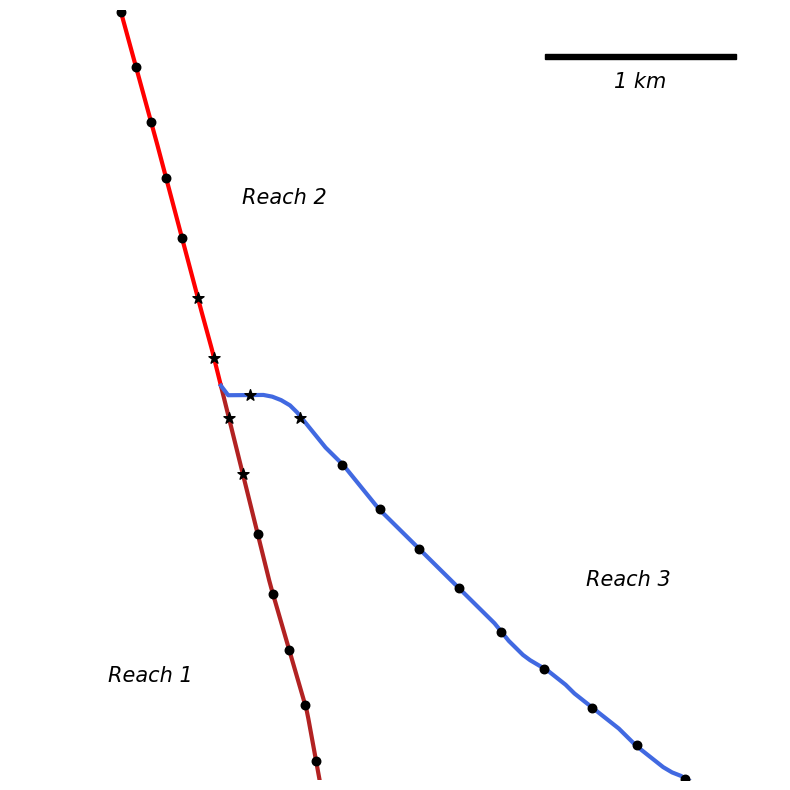

In [114]:
ids = [23267000011, # 1
        23265000061, #2
        23266000011] # 3
gdf  = dfIn[dfIn['reach_id'].isin(ids)].to_crs(3857)
gdfN = dfNodeIn[dfNodeIn['reach_id'].isin(ids)].to_crs(3857)
lineColors  = ['firebrick', 'red', 'royalblue']
w = np.zeros(3)
nodeOrder   = [23267000010011, 23267000010021, 23265000060621, 23265000060611, 23266000010011, 23266000010021]
xys         = [[938500, 6.3605e6], [939200, 6.363e6], [941000, 6.361e6]]
fig, ax = plt.subplots(figsize=(8, 8))

for i, ID in enumerate(ids):
    row  = gdf[gdf['reach_id']   == ID].iloc[0]
    rowN = gdfN[gdfN['reach_id'] == ID]
    ax.plot(*row['geometry'].xy, linewidth = 3, color = lineColors[i], zorder = 0)
    ax.annotate(text = f'Reach {i+1}', xy = xys[i], fontsize = 15)


    for j in range(rowN.shape[0]):
        rn = rowN.iloc[j]

        if (rn['node_id'] in nodeOrder):
            print(rn['width'])
            w[i] += rn['width']
            nc = 'black'
            m = '*'
            s = 70
        else:
            nc = 'black'
            m = '.'
            s = 150

        plt.scatter(*rn['geometry'].xy, c = nc, zorder = 10, marker = m,s = s)


plt.axis('equal')
# plt.axis('off')


# Add scalebar
fontprops = fm.FontProperties(size=15)
scalebar = AnchoredSizeBar(ax.transData,
                           1000,             # length in CRS units (e.g., 1000 meters)
                           '1 km',           # label
                           'upper right',    # position
                           pad=2,sep= 10,
                           color='black',
                           frameon=False,
                           size_vertical=25,
                           fontproperties=fontprops)

ax.add_artist(scalebar)
ax.set_axis_off()
plt.xlim([938000,942000])
plt.ylim([6.360e6, 6.364e6])
plt.savefig(directory + 'results/figures/reach_def.png')
plt.tight_layout()
plt.show()

In [100]:
ids = [23267000011, # 1
        23265000061, #2
        23266000011] # 3
df1  = dfNodeIn[dfNodeIn['reach_id'] == ids[0]]
df2  = dfNodeIn[dfNodeIn['reach_id'] == ids[1]]
df3  = dfNodeIn[dfNodeIn['reach_id'] == ids[2]]

In [102]:
angle1    = azimuth(df1['geometry'].iloc[1], df1['geometry'].iloc[0])
angle2    = azimuth(df2['geometry'].iloc[-1], df2['geometry'].iloc[-2])
angle3    = azimuth(df3['geometry'].iloc[1], df3['geometry'].iloc[0])


da1  = angle_difference(angle1, angle2) # difference in orientation between the two reaches
da2  = angle_difference(angle2, angle3) # difference in orientation between the two reaches
angle1, angle2, angle3, da1, da2

(339.09865641447584,
 337.60905889750546,
 286.3258386253855,
 1.4895975169703775,
 51.28322027211999)

              x          y     reach_id     reach_len  n_nodes        wse  \
12886  8.503974  49.487693  23266000011  11095.101226       56  94.200005   

        wse_var  width    width_var         facc  ...  edit_flag  trib_flag  \
12886  3.227212  105.0  1512.940077  13878.67869  ...        NaN          0   

       path_freq  path_order  path_segs  main_side  strm_order  end_reach  \
12886          1          18         40          0           1          3   

       network                                           geometry  
12886        1  LINESTRING (939089.813 6362048.612, 939127.674...  

[1 rows x 37 columns]


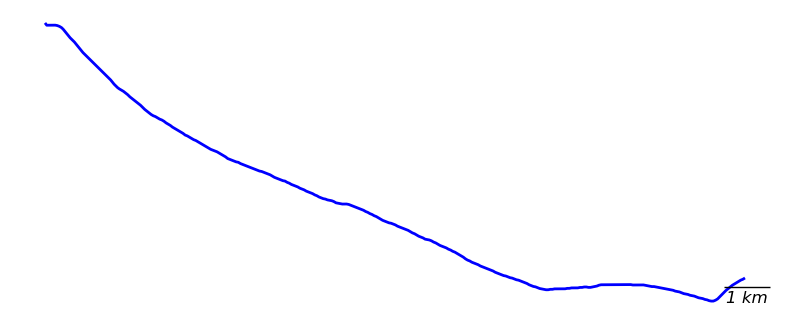

In [29]:
import geopandas as gpd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm

# Load or create a GeoDataFrame with LineStrings (ensure it's projected)

gdf= dfIn[dfIn['reach_id'] == ID]
gdf = gdf.to_crs(epsg=3857)  # Example: Web Mercator (meters)

print(gdf)
# Plot the GeoDataFrame
fig, ax = plt.subplots(figsize=(8, 8))
gdf.plot(ax=ax, color='blue', linewidth=2)

# Add scalebar
fontprops = fm.FontProperties(size=12)
scalebar = AnchoredSizeBar(ax.transData,
                           1000,             # length in CRS units (e.g., 1000 meters)
                           '1 km',           # label
                           'lower right',    # position
                           pad=0.5,
                           color='black',
                           frameon=False,
                           size_vertical=10,
                           fontproperties=fontprops)

ax.add_artist(scalebar)
ax.set_axis_off()
plt.tight_layout()
plt.show()
